In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pysam import AlignmentFile
import pysam
from scipy.signal import savgol_filter
from matplotlib import gridspec
from scipy.stats import gaussian_kde
from matplotlib.colors import ListedColormap

from cuban_lib.visualize import plot_breakpoints_ill_pb, plot_breakpoints_ill

plt.style.use('ggplot')

In [2]:
# Load repeat annotations
repeats = '/confidential/tGenVar/ref/hg38/annotation/hg38_repeatmasker.tsv'
repeat_df = pd.read_csv(repeats, sep='\t')

In [3]:
# Samples
samples = {'16-110' : {'family_status' : 'index',
                       'disease_status' : 'affected',
                       'bam_name' : f'/confidential/typo/cohorts/Udd/aligned_bam/16-110/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                       'baseline_cov' : 30},
           '16-112' : {'family_status' : 'father',
                       'disease_status' : 'unaffected',
                       'bam_name' : f'/confidential/typo/cohorts/Udd/aligned_bam/16-112/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                       'baseline_cov' : 30},
           '16-113' : {'family_status' : 'mother',
                       'disease_status' : 'unaffected',
                       'bam_name' : f'/confidential/typo/cohorts/Udd/aligned_bam/16-113/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                       'baseline_cov' : 30}}

# Region
chrom = 'chr5'
start = 139322504
stop = start + 50

In [4]:
# Samples
samples = {'S8388Nr27' : {'family_status' : 'index',
                       'disease_status' : 'affected',
                       'bam_name' : f'/confidential/typo/cohorts/Udd/aligned_bam/S8388Nr27/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                       'baseline_cov' : 30}}

# Region
chrom = 'chrX'
start = 31551000
stop = 32135379

In [5]:
rep_y_pos_map = {'LINE' : (-6, '#6ac0b7'),
                 'SINE' : (-14, '#b7954b'),
                 'LTR' : (-22, '#f0b6a0'),
                 'DNA' : (-30, '#5066a2'),
                 'Simple_repeat' : (-38, '#504669'),
                 'Satellite' : (-46, '#df624c'),
                 'Low_complexity' : (-54, '#61856b'),
                 'Retroposon' : (-62, '#2f7155')}

116875


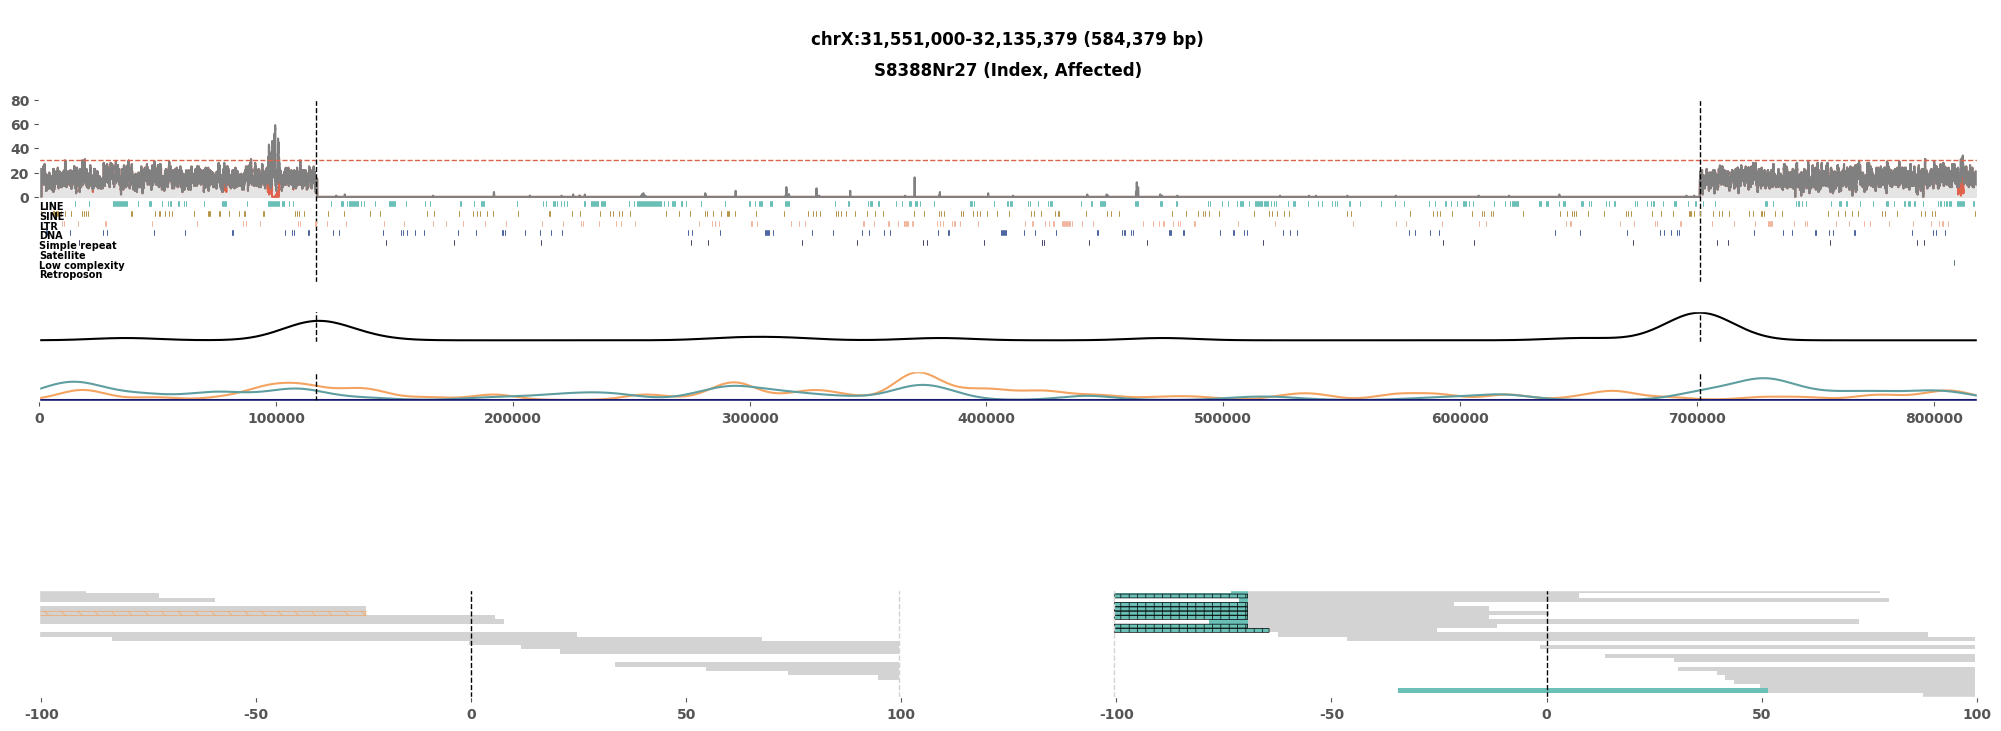

In [6]:
plot_breakpoints_ill(samples, repeat_df, chrom, start, stop, padding=1500, window=100, collapse_ins=False)

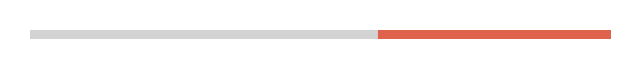

In [38]:
colors = ['white', 'lightgrey', '#b7954b', '#5066a2', '#f0b6a0', '#6ac0b7', '#df624c', 'lightgrey', 'lightgrey']
# Create a figure and an axes, making the background transparent
fig, ax = plt.subplots(figsize=(2.5, 0.04), dpi=300)
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Plot a lightgray rectangle with height 1 and width 10
rectangle = plt.Rectangle((0, 0), 1, 0.05, color='lightgrey')
ax.add_patch(rectangle)

# Plot a small blue portion on the rectangle
blue_portion = plt.Rectangle((0.6, 0), 0.4, 0.05, color='#df624c')  # Adjust the width as needed for the "small portion"
ax.add_patch(blue_portion)

# Remove axes
ax.axis('off')
ax.set_ylim(0, 0.05)

# Display the plot
plt.savefig('match.png', dpi=300, bbox_inches='tight', transparent=True)